# **Random Forest**

In [ ]:
import pandas as pd
data = { "CGPA": [9.1, 8.5, 7.2, 9.4, 8.0, 6.8, 9.0, 7.8, 8.9, 6.5, 9.3, 7.1],
        "Projects": [5, 3, 1, 6, 2, 1, 5, 2, 4, 1, 6, 2],
         "Internship": [1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0],
         "Communication":[9, 7, 5, 9, 6, 4, 8, 6, 8, 4, 9, 5],
         "Placed": [1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0] }
df = pd.DataFrame(data)
df

,CGPA,Projects,Internship,Communication,Placed
0,9.1,5,1,9,1
1,8.5,3,1,7,1
2,7.2,1,0,5,0
3,9.4,6,1,9,1
4,8.0,2,0,6,0
5,6.8,1,0,4,0
6,9.0,5,1,8,1
7,7.8,2,0,6,0
8,8.9,4,1,8,1
9,6.5,1,0,4,0


In [ ]:
from sklearn.model_selection import train_test_split
x=df.drop("Placed",axis=1)
y=df["Placed"]

x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=5,
                          random_state=42,
                          bootstrap=True,
                          max_depth=5
                          )
rf.fit(x_train,y_train)

RandomForestClassifier(max_depth=5, n_estimators=5, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score
prediction = rf.predict(x_test)
print("Accuracy : ",accuracy_score(y_test,prediction))

Accuracy :  1.0


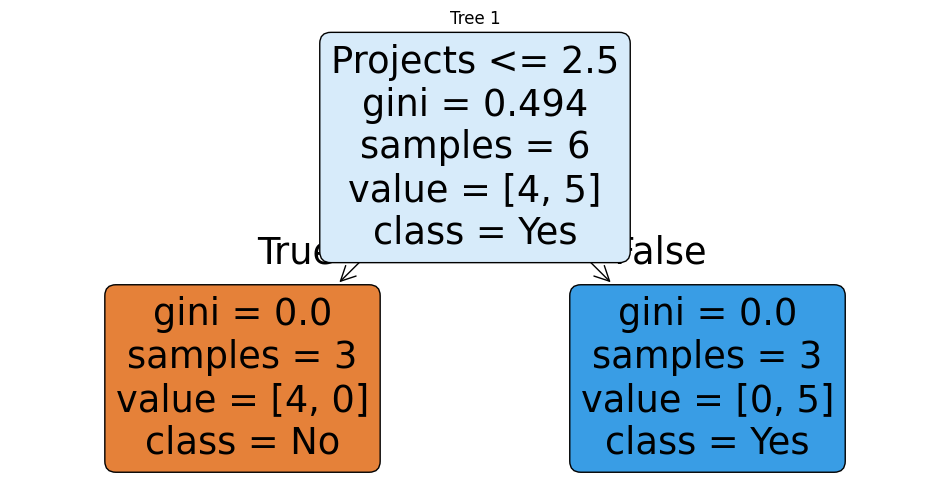

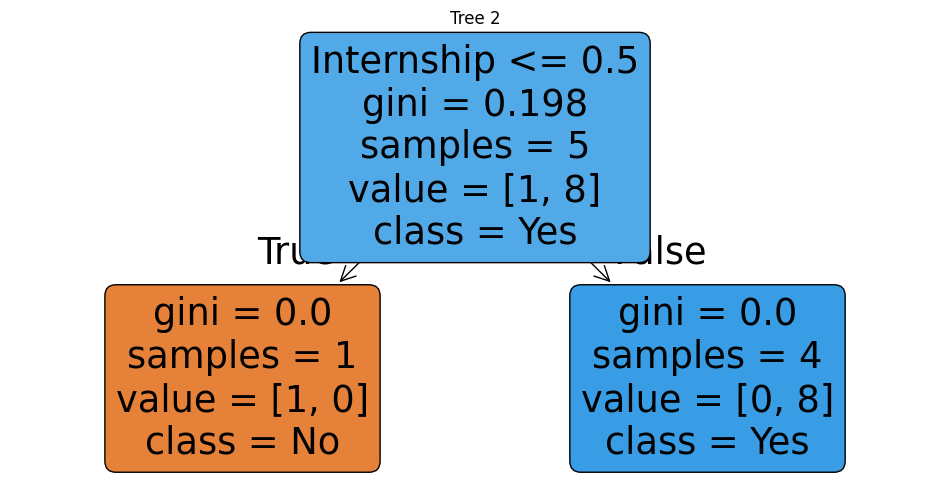

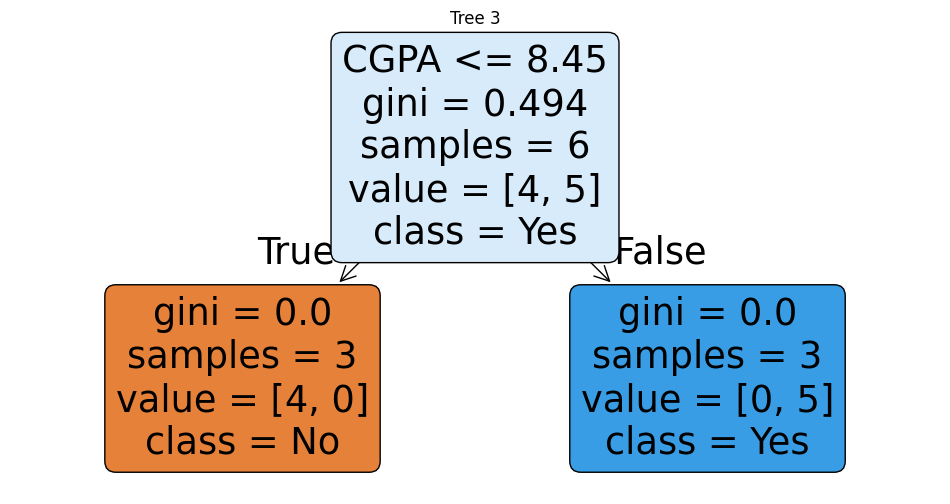

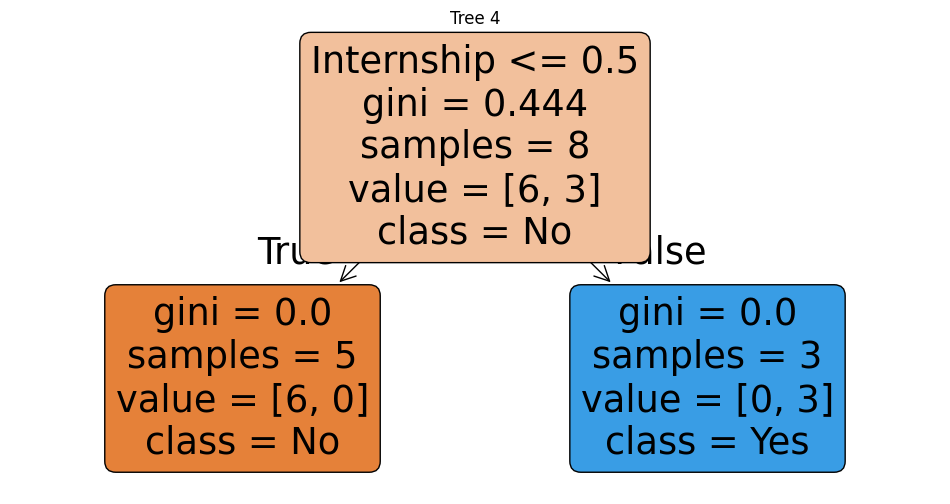

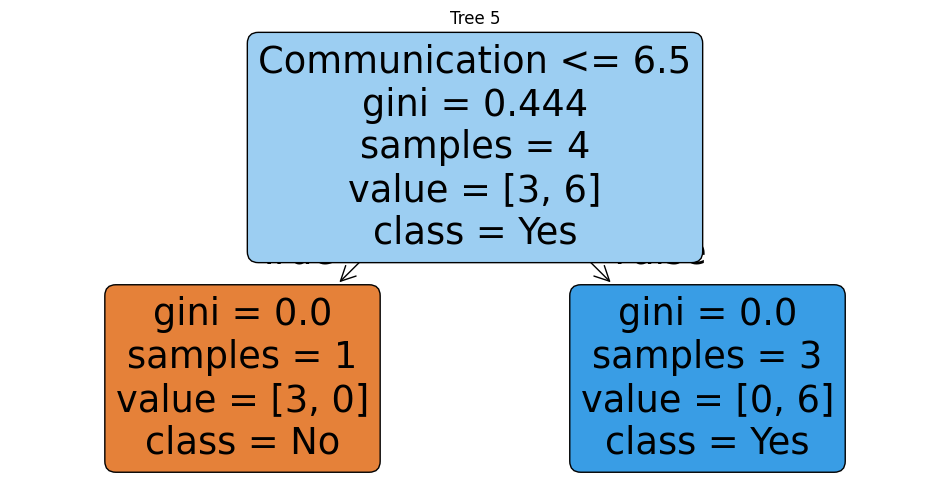

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

for i, estimator in enumerate(rf.estimators_):
  plt.figure(figsize=(12,6))

  tree.plot_tree(
      estimator,
      feature_names=x.columns,
      class_names=["No","Yes"],
      filled=True,
      rounded=True
  )
  plt.title(f"Tree {i+1}")
  plt.show

# **ADABOOST**

In [ ]:
 import pandas as pd

df = pd.DataFrame({

    "Student":["S1","S2","S3","S4","S5","S6"],

    "CGPA":[9.5,8.8,8.2,7.4,6.8,6.2],

    "Communication":[6,9,4,9,5,3],

    "Placed":[1,1,0,1,0,0]

})

df

,Student,CGPA,Communication,Placed
0,S1,9.5,6,1
1,S2,8.8,9,1
2,S3,8.2,4,0
3,S4,7.4,9,1
4,S5,6.8,5,0
5,S6,6.2,3,0


In [ ]:
df["Weight"]=1/6
df

,Student,CGPA,Communication,Placed,Weight
0,S1,9.5,6,1,0.166667
1,S2,8.8,9,1,0.166667
2,S3,8.2,4,0,0.166667
3,S4,7.4,9,1,0.166667
4,S5,6.8,5,0,0.166667
5,S6,6.2,3,0,0.166667


In [ ]:
df["Prediction"]=(df["CGPA"]>8).astype(int)
df

,Student,CGPA,Communication,Placed,Weight,Prediction
0,S1,9.5,6,1,0.166667,1
1,S2,8.8,9,1,0.166667,1
2,S3,8.2,4,0,0.166667,1
3,S4,7.4,9,1,0.166667,0
4,S5,6.8,5,0,0.166667,0
5,S6,6.2,3,0,0.166667,0


In [ ]:
wrong=df["Placed"]!=df["Prediction"]
error1 = df.loc[wrong,"Weight"].sum()
print(error1)

0.3333333333333333


In [ ]:
import numpy as np
alpha1 = 0.5*np.log((1-error1)/error1)
print(alpha1)

0.34657359027997275


In [ ]:
new_weights=[]
for actual,pred,w in zip(df["Placed"],
                         df["Prediction"],
                         df["Weight"]):
  if actual==pred:
    new_weights.append(w*np.exp(-alpha1))
  else:
    new_weights.append(w*np.exp(alpha1))

In [ ]:
#normalize the weights

new_weights=np.array(new_weights)
new_weights=new_weights/new_weights.sum()
df["Weight Round2"]=new_weights

df

,Student,CGPA,Communication,Placed,Weight,Prediction,Weight Round2
0,S1,9.5,6,1,0.166667,1,0.125
1,S2,8.8,9,1,0.166667,1,0.125
2,S3,8.2,4,0,0.166667,1,0.250
3,S4,7.4,9,1,0.166667,0,0.250
4,S5,6.8,5,0,0.166667,0,0.125
5,S6,6.2,3,0,0.166667,0,0.125


In [ ]:
df["Prediction2"]=(df["Communication"]>7).astype(int)
df

,Student,CGPA,Communication,Placed,Weight,Prediction,Weight Round2,Prediction2
0,S1,9.5,6,1,0.166667,1,0.125,0
1,S2,8.8,9,1,0.166667,1,0.125,1
2,S3,8.2,4,0,0.166667,1,0.250,0
3,S4,7.4,9,1,0.166667,0,0.250,1
4,S5,6.8,5,0,0.166667,0,0.125,0
5,S6,6.2,3,0,0.166667,0,0.125,0


In [ ]:
wrong=df["Placed"]!= df["Prediction2"]
error2 = df.loc[wrong,"Weight Round2"].sum()
print(error2)

0.12499999999999999


In [ ]:
alpha2=0.5*np.log((1-error2)/error2)
print(alpha2)

0.9729550745276567


## Alpha2 > Alpha1 -> Second stump made fewer mistakes

In [ ]:
weights = []

for actual,pred,w in zip(df["Placed"],
                         df["Prediction2"],
                         df["Weight Round2"]):
  if actual==pred:
    weights.append(w*np.exp(-alpha2))
  else:
    weights.append(w*np.exp(alpha2))

In [ ]:
weights=np.array(weights)
weights=weights/weights.sum()
df["Weight Round3"]=weights
df

,Student,CGPA,Communication,Placed,Weight,Prediction,Weight Round2,Prediction2,Weight Round3
0,S1,9.5,6,1,0.166667,1,0.125,0,0.500000
1,S2,8.8,9,1,0.166667,1,0.125,1,0.071429
2,S3,8.2,4,0,0.166667,1,0.250,0,0.142857
3,S4,7.4,9,1,0.166667,0,0.250,1,0.142857
4,S5,6.8,5,0,0.166667,0,0.125,0,0.071429
5,S6,6.2,3,0,0.166667,0,0.125,0,0.071429


In [ ]:
tree1=df["Prediction"].replace({0:-1,1:1})
tree2=df["Prediction2"].replace({0:-1,1:1})
score=alpha1*tree1+alpha2*tree2
score


,0
0,-0.626381
1,1.319529
2,-0.626381
3,0.626381
4,-1.319529
5,-1.319529


In [ ]:
final_prediction=(score>0).astype(int)
df["Final Prediction"]=final_prediction
df

,Student,CGPA,Communication,Placed,Weight,Prediction,Weight Round2,Prediction2,Weight Round3,Final Prediction
0,S1,9.5,6,1,0.166667,1,0.125,0,0.500000,0
1,S2,8.8,9,1,0.166667,1,0.125,1,0.071429,1
2,S3,8.2,4,0,0.166667,1,0.250,0,0.142857,0
3,S4,7.4,9,1,0.166667,0,0.250,1,0.142857,1
4,S5,6.8,5,0,0.166667,0,0.125,0,0.071429,0
5,S6,6.2,3,0,0.166667,0,0.125,0,0.071429,0


In [ ]:
from sklearn.metrics import accuracy_score
print("accuary", accuracy_score(df["Placed"],final_prediction))

accuary 0.8333333333333334


In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
ada = AdaBoostClassifier(
    n_estimators=20,
    learning_rate=1,
    random_state=42)
ada.fit(x_train,y_train)
ada_prediction=ada.predict(x_test)
print("Accuracy : ",accuracy_score(y_test,ada_prediction))

Accuracy :  1.0


In [ ]:
print("AdaBoost Accuracy")
print(accuracy_score(y_test,ada_prediction))

AdaBoost Accuracy
1.0


In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,ada_prediction))

[[1 0]
 [0 2]]


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,ada_prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



# **Bayes theorem**

In [ ]:
import pandas as pd

In [ ]:
df = pd.DataFrame({
'CGPA':['High','High','Medium','Medium','Low','Low','High','Medium','Low','High'],
'Communication':['Good','Poor','Good','Poor','Good','Poor','Good','Good','Poor','Poor'],
'Placed':['Yes','Yes','Yes','No','No','No','Yes','Yes','No','Yes']
})

df

,CGPA,Communication,Placed
0,High,Good,Yes
1,High,Poor,Yes
2,Medium,Good,Yes
3,Medium,Poor,No
4,Low,Good,No
5,Low,Poor,No
6,High,Good,Yes
7,Medium,Good,Yes
8,Low,Poor,No
9,High,Poor,Yes
